In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [13]:
#config
FILES = ["S07main_EpochedNoseRefCleanTimesFixed.mat"] 
FSAMPLE     = 512
TOTAL_TIMES = 1229
T_STIMULUS  = 822   #index of stimulus onset (t=0 s)
T_POST      = 407   #post-stimulus samples
BANDS = {"delta":(1,4), "theta":(4,8), "alpha":(8,13), "beta":(13,30)} #different bands for spectral analysis

In [14]:
#method to extract data from .mat files
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0,0] if item.size==1 and item.ndim>1 else (item[0] if item.size==1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0,0]

def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0,0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v); trials.extend(t)
    trials = np.array(trials); vals = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]   #labels {0,1}, trials

In [15]:
y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)   #trials, timesteps, channels
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")

Trials: 222  |  Class 0: 134  Class 1: 88


In [16]:
#split the data
X_tr_raw, X_tmp, y_train, y_tmp = train_test_split(X_full, y, test_size=0.4, random_state=42)
X_val_raw, X_te_raw, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

#normalise the data seperately
mean = X_tr_raw.mean(axis=(0,1), keepdims=True)
std  = X_tr_raw.std(axis=(0,1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_val   = (X_val_raw - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)}")

Train/Val/Test: 133/44/45


In [17]:
#experimenting with spectral density analysis + feature extraction
def band_powers(X):
    n, t, ch = X.shape
    feats = np.zeros((n, len(BANDS) * ch))
    for i in range(n):
        freqs, psd = welch(X[i], fs=FSAMPLE, axis=0, nperseg=min(256, t))
        bp = [psd[(freqs>=lo)&(freqs<=hi)].mean(axis=0) for lo,hi in BANDS.values()]
        feats[i] = np.concatenate(bp)
    return feats

def erp_features(X):
    s = FSAMPLE
    wins = [(0, int(0.2*s)), (int(0.2*s), int(0.4*s)), (int(0.4*s), X.shape[1])]
    return np.concatenate([X[:,a:b,:].mean(axis=1) for a,b in wins], axis=1)

def extract(X):
    post = X[:, T_STIMULUS:T_STIMULUS+T_POST, :]
    return np.concatenate([band_powers(post), erp_features(post)], axis=1)

#Scaling the data using StandardScaler
print("Extracting features...")
Xf_tr = extract(X_train); Xf_va = extract(X_val); Xf_te = extract(X_test)
scaler = StandardScaler()
Xf_tr = scaler.fit_transform(Xf_tr)
Xf_va = scaler.transform(Xf_va)
Xf_te = scaler.transform(Xf_te)
print(f"Feature shape: {Xf_tr.shape}")

Extracting features...
Feature shape: (133, 448)


In [18]:
#SMOTE oversampling technique
sm = SMOTE(random_state=42)
Xf_tr_sm, y_tr_sm = sm.fit_resample(Xf_tr, y_train)
print(f"After SMOTE — Class 0: {(y_tr_sm==0).sum()}  Class 1: {(y_tr_sm==1).sum()}")

After SMOTE — Class 0: 82  Class 1: 82


In [19]:
#method to show results uniformly
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()


  Logistic Regression — Normal data
              precision    recall  f1-score   support

     Class 0     0.7600    0.7600    0.7600        25
     Class 1     0.7000    0.7000    0.7000        20

    accuracy                         0.7333        45
   macro avg     0.7300    0.7300    0.7300        45
weighted avg     0.7333    0.7333    0.7333        45



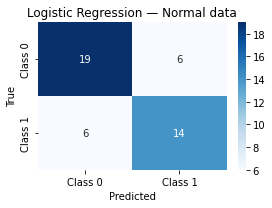


  Logistic Regression — SMOTE data
              precision    recall  f1-score   support

     Class 0     0.7500    0.7200    0.7347        25
     Class 1     0.6667    0.7000    0.6829        20

    accuracy                         0.7111        45
   macro avg     0.7083    0.7100    0.7088        45
weighted avg     0.7130    0.7111    0.7117        45



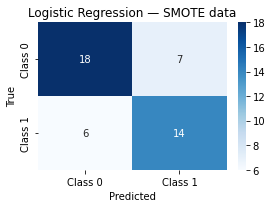

In [27]:
#logistic regression trained on normal data
lr_normal = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_normal.fit(Xf_tr, y_train)
show_results("Logistic Regression — Normal data", y_test, lr_normal.predict(Xf_te))

#logistic regression trained on SMOTE data
lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_smote.fit(Xf_tr_sm, y_tr_sm)
show_results("Logistic Regression — SMOTE data", y_test, lr_smote.predict(Xf_te))